# VascX features on real photographs — a traced mask against the expert's own

**Work in progress.** Nothing here is a benchmark result and nothing is committed as evidence.

The [synthetic benchmark](../../docs/benchmarks/biomarker-synthetic-results.md) measures VascX
against shapes whose values follow from geometry, and its §8 says plainly what that cannot settle:
*that any of this transfers to photographs*. Every synthetic vessel is clean, complete, unbroken
and drawn to a known scale. This notebook asks the next question on the same code.

**What it does.** For a few photographs it runs VascX's feature extraction **twice** — once on the
artery/vein map a human expert drew, and once on the map VascX's own segmentation model produced
from the same photograph — and puts the two columns side by side. Everything else is held
identical: the same field of view, the same optic disc, the same scale, the same feature set, the
same pass of the same code. **So the difference between the two columns is the segmentation and
nothing else.**

That is the quantity nobody can get from a synthetic shape and nobody can get from a dataset of
photographs alone. A Dice score says how many pixels a segmenter got right; it does not say what
that costs the number a clinician would read.

**Why HRF.** It is the highest-resolution artery/vein reference this atlas has a store for —
3,271 × 3,271 after cropping to the field of view, at about 5 µm per pixel — and both the expert's
map and the model's prediction are already on that same grid, so neither is resampled before it is
measured. Forty-five photographs, fifteen each of healthy, diabetic-retinopathy and glaucoma eyes.

**One caveat before any micron below is believed.** HRF published no microns-per-pixel figure. The
scale used here is this repository's own, **inferred** by assuming the median optic disc of a
sample is 1,800 µm across — `resolution_source` is `disc_anchored`, and
[results/um_resolution/hrf.json](../../results/um_resolution/hrf.json) records how. It is good to
roughly a tenth, and no disc size in millimetres may be quoted off it. The comparison this
notebook is actually for — one column against the other — is unaffected, because both columns use
the same scale.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image


def repository() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(f"nothing above {Path.cwd()} looks like the fundus-atlas repository")


ROOT = repository()
sys.path.insert(0, str(ROOT / "src"))

from biomarkers import canonical  # noqa: E402
from biomarkers.utils import catalogue as biomarkers  # noqa: E402
from models.utils import catalogue as models  # noqa: E402

#: The dataset, and where its two halves live. The expert's maps are in the committed store; the
#: model's are what the artery/vein benchmark left behind, which is why that directory is a run
#: rather than a result — see `build-benchmark` §6.
DATASET = "hrf"
STORE = ROOT / ".atlas_data" / DATASET / "native"
PREDICTED = ROOT / ".atlas_runs" / "av" / "vascx-artery-vein" / DATASET

#: One photograph of each kind HRF holds. A few pairs, deliberately: this is 15 seconds of VascX
#: per mask at this resolution, and the point is to look at the numbers rather than to average them.
KEYS = ("01_h", "01_dr", "01_g")

manifest = pd.read_csv(ROOT / ".atlas_data" / DATASET / "manifest.csv").set_index("key")
UM_PER_PX = float(manifest["um_per_px"].iloc[0])
SCALE_SOURCE = str(manifest["resolution_source"].iloc[0])

for place in (STORE, PREDICTED):
    if not place.exists():
        raise RuntimeError(
            f"{place.relative_to(ROOT)} is not there. The store is built with "
            f"`python -m datasets.{DATASET}`, and the predicted masks are left by "
            f"`python -m benchmarks --benchmark av --model vascx-artery-vein --dataset {DATASET}`."
        )

print(f"{DATASET}: {len(manifest)} photographs, {UM_PER_PX:g} µm per pixel ({SCALE_SOURCE})")
print(f"reading {len(KEYS)} of them: {', '.join(KEYS)}")
print(f"  expert maps   {STORE.relative_to(ROOT)}")
print(f"  VascX's maps  {PREDICTED.relative_to(ROOT)}")

hrf: 45 photographs, 4.9802 µm per pixel (disc_anchored)
reading 3 of them: 01_h, 01_dr, 01_g
  expert maps   .atlas_data/hrf/native
  VascX's maps  .atlas_runs/av/vascx-artery-vein/hrf


## 1. The pairs

Each row is one photograph: what the camera saw, what the expert drew, and what VascX's
segmentation model produced from it. Arteries red, veins blue — **the atlas's convention, not the
file's**: each map is two separate binary masks and the colour is only put on here so a reader can
see both at once.

Look at the two mask columns rather than at the agreement score. Where they differ is almost never
the trunk: it is the thin peripheral branches, where a vessel either continues or stops, and where
every length, every count and every junction-based measurement is decided.

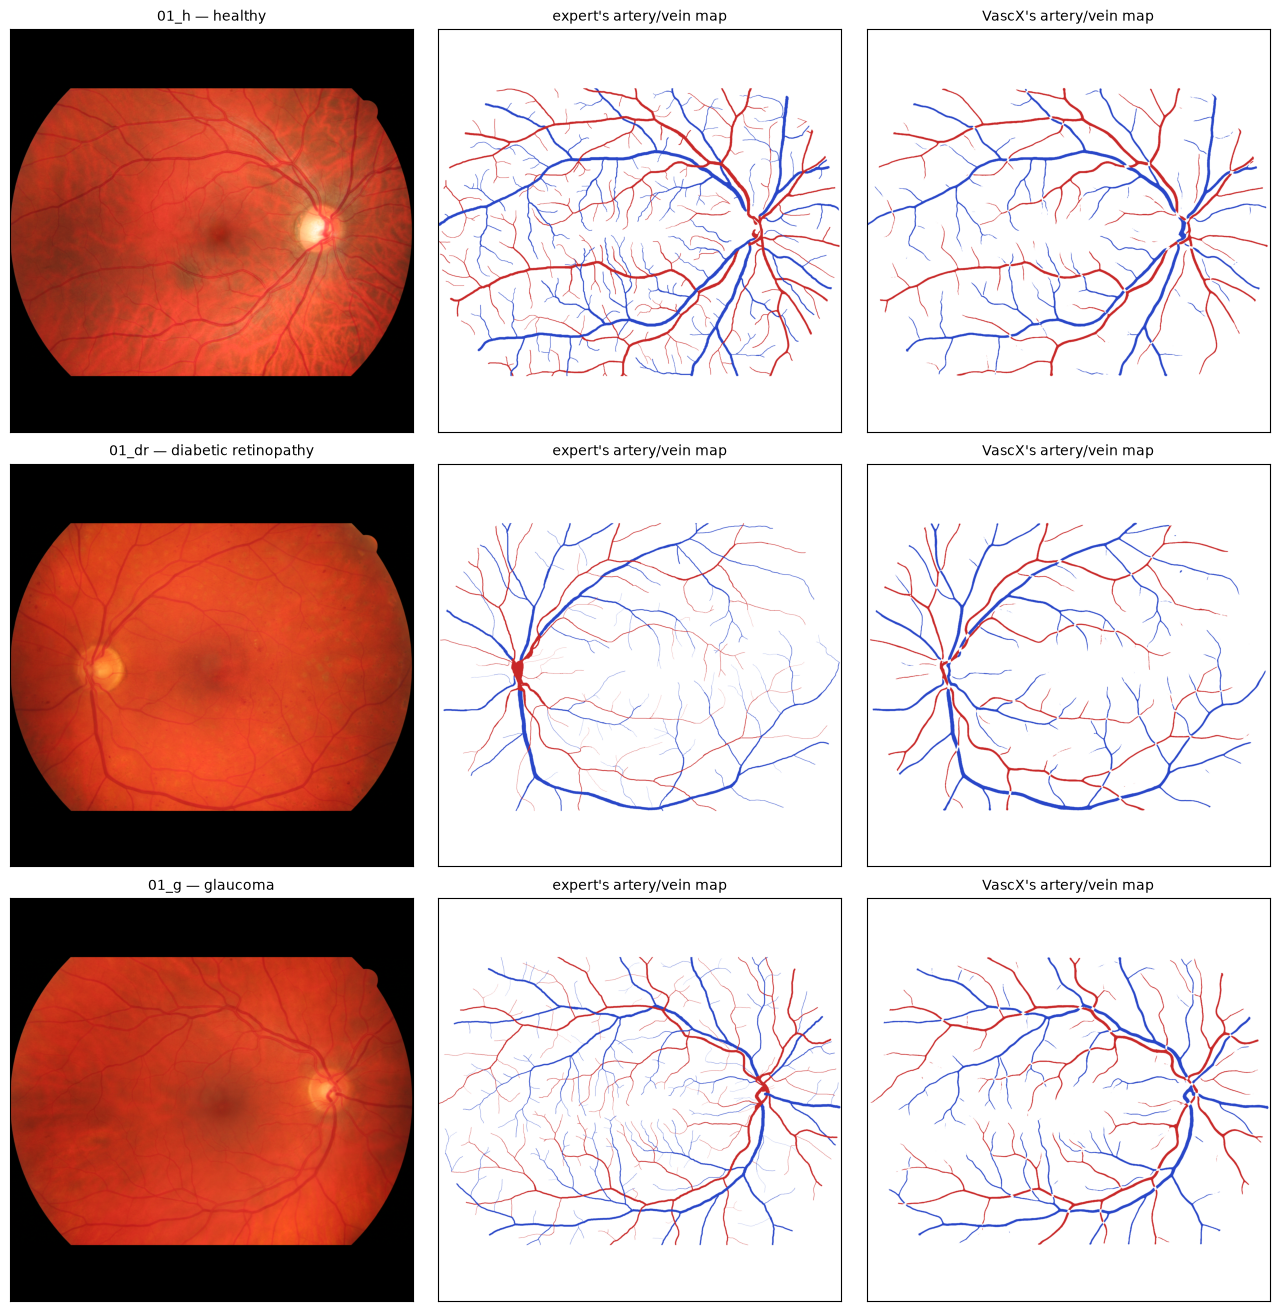

In [2]:
def mask(path: Path) -> np.ndarray:
    """One binary map, as it sits on disk. Nothing is resampled anywhere in this notebook."""
    return np.array(Image.open(path)) > 0


def expert(key: str) -> dict[str, np.ndarray]:
    return {
        "artery": mask(STORE / "artery" / f"{key}.png"),
        "vein": mask(STORE / "vein" / f"{key}.png"),
    }


def predicted(key: str) -> dict[str, np.ndarray]:
    return {
        "artery": mask(PREDICTED / f"{key}-artery.png"),
        "vein": mask(PREDICTED / f"{key}-vein.png"),
    }


def painted(maps: dict[str, np.ndarray]) -> np.ndarray:
    """Both classes in one picture, on white, so two maps can be compared at a glance."""
    canvas = np.ones((*maps["artery"].shape, 3), dtype=np.uint8) * 255
    canvas[maps["vein"]] = (40, 70, 200)
    canvas[maps["artery"]] = (200, 40, 40)
    return canvas


PHOTOGRAPHS = {key: np.array(Image.open(STORE / "images" / f"{key}.png").convert("RGB"))
               for key in KEYS}
FIELDS = {key: mask(STORE / "fov" / f"{key}.png") for key in KEYS}
EXPERT = {key: expert(key) for key in KEYS}
VASCX = {key: predicted(key) for key in KEYS}

figure, axes = plt.subplots(len(KEYS), 3, figsize=(13, 4.4 * len(KEYS)))
for row, key in enumerate(KEYS):
    disease = manifest.loc[key, "disease"]
    for column, (title, picture) in enumerate(
        (
            (f"{key} — {disease}", PHOTOGRAPHS[key]),
            ("expert's artery/vein map", painted(EXPERT[key])),
            ("VascX's artery/vein map", painted(VASCX[key])),
        )
    ):
        axis = axes[row, column]
        axis.imshow(picture)
        axis.set_title(title, fontsize=10)
        axis.set_xticks([])
        axis.set_yticks([])
figure.tight_layout()
plt.show()

## 2. The optic disc, found once and shared

VascX builds a retina around the optic disc: its zones are annuli measured from the disc margin,
and its tortuosity and calibre are reported over a circle at 1.1667 disc diameters. So the disc has
to come from somewhere, and HRF's store carries none.

It is taken from **[vascx-disc](../../docs/models/vascx-disc.md)**, VascX's own disc model, run on
the photograph — which is what the shipped pipeline does.

**The same disc is given to both runs of each pair**, and that is the whole design of this
notebook. Finding the disc separately for each would let a difference in the disc leak into a
comparison meant to isolate the segmentation. Here the artery/vein map is the only thing that
differs between the two columns.

In [3]:
def disc_of(image: np.ndarray, model) -> tuple[float, float, float]:
    """Where the optic disc is, as the centre and radius VascX's feature code asks for.

    The model reads a 1024-pixel square and returns its answer on the photograph's own frame, so
    the centre and radius below are in native pixels — the frame the masks are in.
    """
    side = image.shape[0]
    small = np.array(Image.fromarray(image).resize((model.grid, model.grid), Image.BILINEAR))
    found = model.outline(torch.stack([model.prepare(small)]), [side])[0]
    if found.outcome != "graded" or not found.masks["disc"].any():
        raise RuntimeError(f"no disc found: {found.outcome} {found.note}")
    ys, xs = np.nonzero(found.masks["disc"])
    # A radius from the area rather than from the extent: the outline is not a circle, and the
    # area is what the equivalent of a circle is built on.
    return float(xs.mean()), float(ys.mean()), float(np.sqrt(found.masks["disc"].sum() / np.pi))


disc_model = models.load("vascx-disc")
DISCS = {key: disc_of(PHOTOGRAPHS[key], disc_model) for key in KEYS}
disc_model.release()

pd.DataFrame(
    [
        {
            "photograph": key,
            "disease": manifest.loc[key, "disease"],
            "frame, px": PHOTOGRAPHS[key].shape[0],
            "disc x": round(DISCS[key][0]),
            "disc y": round(DISCS[key][1]),
            "disc radius, px": round(DISCS[key][2]),
            "disc diameter, µm": round(2 * DISCS[key][2] * UM_PER_PX),
        }
        for key in KEYS
    ]
).set_index("photograph")

/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1643: FutureWarning: `torch.jit.interface` is deprecated. Please use `torch.compile` instead.
  warnings.warn(


/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/albumentations/core/composition.py:250: UserWarning: Got processor for keypoints, but no transform to process it.
  self._set_keys()


/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:362.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)


/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:362.)
  out[idx_zm] += p


/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:362.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered i

/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:362.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered i

,disease,"frame, px",disc x,disc y,"disc radius, px","disc diameter, µm"
photograph,,,,,,
01_h,healthy,3270,2523,1625,184,1837
01_dr,diabetic retinopathy,3271,724,1668,186,1853
01_g,glaucoma,3268,2586,1558,174,1733


**Read that last column with the caveat from the top in mind.** The scale was *defined* by
assuming the median disc of a sample is 1,800 µm, so a disc measuring near 1,800 µm here is
mostly the assumption coming back. What it does say is how far *this* eye's disc sits from the
median of the sample the scale was inferred from, which is worth a glance before trusting any
absolute micron figure for that photograph.

## 3. VascX, run twice on each photograph

Same adapter, same shipped feature set, same disc, same field of view, same scale. The artery/vein
map is the only input that changes.

The adapter reports what VascX returned under **VascX's own column names**, because that is what
its authors call these numbers and what a reader checking against their paper will look for. Where
a column answers to a catalogued biomarker the name is shown beside it, and the value is converted
into the unit that name declares — microns, µm², 1/µm, never pixels. Both columns are converted
the same way, so the difference between them is in the segmentation rather than in the
arithmetic.

In [4]:
adapter = biomarkers.load("vascx")
NAMES = adapter.declare()["names"]


def run(key: str, maps: dict[str, np.ndarray]) -> tuple[dict[str, float | None], float, dict]:
    """One pass of VascX over one artery/vein map, timed, with whatever it complained about."""
    started = time.time()
    answered = adapter.measure(
        maps["artery"], maps["vein"], FIELDS[key], DISCS[key], UM_PER_PX
    )
    return answered, time.time() - started, dict(adapter.trouble)


MEASURED: dict[tuple[str, str], dict[str, float | None]] = {}
TIMING = []
for key in KEYS:
    for source, maps in (("expert", EXPERT[key]), ("vascx", VASCX[key])):
        answered, seconds, trouble = run(key, maps)
        MEASURED[(key, source)] = answered
        TIMING.append(
            {
                "photograph": key,
                "map": source,
                "seconds": round(seconds, 1),
                "values returned": sum(value is not None for value in answered.values()),
                "of": len(answered),
                "trouble": "; ".join(trouble) or "—",
            }
        )
        print(f"  {key:7s} {source:7s} {seconds:5.1f}s")

adapter.release()
pd.DataFrame(TIMING).set_index(["photograph", "map"])

/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(
/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(
/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(
/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(


/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(


/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(
/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(


/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(
/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(
/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(


  01_h    expert   12.5s


...

  01_dr   vascx     9.9s


  01_g    expert   11.4s


/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(


  01_g    vascx    10.1s


seconds  values returned  of trouble
photograph map                                         
01_h       expert     12.5               18  20       —
           vascx      10.2               18  20       —
01_dr      expert     11.4               18  20       —
           vascx       9.9               18  20       —
01_g       expert     11.4               16  20       —
           vascx      10.1               16  20       —

## 4. What the segmentation cost

One row per quantity VascX returned, one pair of columns per photograph: the value measured on the
expert's map, the value measured on VascX's own, and the difference as a percentage of the
expert's.

**The expert's column is not the truth.** It is one reader's tracing, and HRF's artery/vein
standard comes from a single group rather than from several readers who could be compared with one
another. So read a difference here as *how far the model's map moves the number away from a
careful human's*, which is not the same claim as an error.

In [5]:
#: Below this, a difference is not reported as a percentage. A biomarker whose value is near
#: nought on a real retina — an inflection count that happens to be small — would otherwise show a
#: vast percentage for a change nobody could see. The same reasoning as the synthetic benchmark's
#: noise floor, and the same 1%, taken here against the expert's own value.
FLOOR = 0.01


def comparison(key: str) -> pd.DataFrame:
    expert_said, vascx_said = MEASURED[(key, "expert")], MEASURED[(key, "vascx")]
    rows = []
    for own in NAMES:
        on_expert, on_vascx = expert_said.get(own), vascx_said.get(own)
        if on_expert is None and on_vascx is None:
            continue
        catalogued = NAMES[own]
        unit = canonical.unit(catalogued) if catalogued else ""
        if catalogued and on_expert is not None:
            on_expert = canonical.from_pixels(catalogued, on_expert, UM_PER_PX)
        if catalogued and on_vascx is not None:
            on_vascx = canonical.from_pixels(catalogued, on_vascx, UM_PER_PX)
        moved = None
        if on_expert is not None and on_vascx is not None:
            denominator = max(abs(on_expert), FLOOR * abs(on_expert) or FLOOR)
            moved = 100.0 * (on_vascx - on_expert) / denominator
        rows.append(
            {
                "VascX's own name": own,
                "on the expert's map": on_expert,
                "on VascX's map": on_vascx,
                "moved, %": moved,
                "unit": unit or "—",
                "catalogued as": catalogued or "—",
            }
        )
    return pd.DataFrame(rows).set_index("VascX's own name")


for key in KEYS:
    disease = manifest.loc[key, "disease"]
    print(f"\n{'=' * 100}\n{key} — {disease}\n{'=' * 100}")
    table = comparison(key)
    with pd.option_context("display.width", 200, "display.max_columns", 20):
        print(table.round(4).to_string())


01_h — healthy
                                                                               on the expert's map  on VascX's map  moved, % unit                                catalogued as
VascX's own name                                                                                                                                                              
lw_diam_crcl_multiplier_1p16666666667_full_arteries                                        56.5719         66.7798   18.0440   µm         calibre/width/artery/length-weighted
full_cre_arteries                                                                         170.2111        155.1904   -8.8247   µm                calibre/CRE-knudtson/artery/B
lw_tort_dist_max_segment_len_0p2_crcl_multiplier_1p16666666667_full_arteries                1.0279          1.0125   -1.4967    1  tortuosity/hart-tau1/artery/length-weighted
lw_tort_dist_max_segment_len_0p15_crcl_multiplier_1p16666666667_full_arteries               1.0231          1

### 4.2 What this notebook found on its first run

**A mapping was withdrawn because of the table above.** `lw_tort_curv` was mapped to
`tortuosity/spline-curvature`, a curvature in 1/µm. On the first run of this notebook it read
about **7.6 per pixel**, which is 1.5 /µm — a vessel turning through a radius of two thirds of a
micron. Impossible on sight.

Reading `vascx/fundus/features/tortuosity.py` says why: `_compute_for_segment` returns
`np.mean(spline.curvatures()) * self._get_curvature_scale(...)`, and that scale is
`layer.retina.disc_fovea_distance`. A curvature multiplied by a length is **dimensionless** — the
number is in disc-to-fovea units. It is the same normalisation that took `mean_sparsity` out of the
catalogue the day before, in a second feature of the same project. Both mappings are now withdrawn
([BIOMARKER-NAMES.md](../../docs/BIOMARKER-NAMES.md) §5), which is why that row shows no unit and
no catalogued name above.

**The synthetic benchmark could not have found this.** There the same column reads 0.0002 to 0.013
and looks merely noisy, because a drawn shape has no macula and the disc-to-fovea distance is a
convention the adapter invents. It took a photograph of a real eye, where that distance is a real
length, for the magnitude to become absurd.

That is the argument for this notebook existing, and it is worth stating plainly: **the synthetic
shapes check the arithmetic, and only a real retina checks whether the quantity is the one its
name claims.**

### 4.1 The same thing in one picture

How far each quantity moved, per photograph. A bar at zero means the model's map and the expert's
produced the same number; the sign says which way.

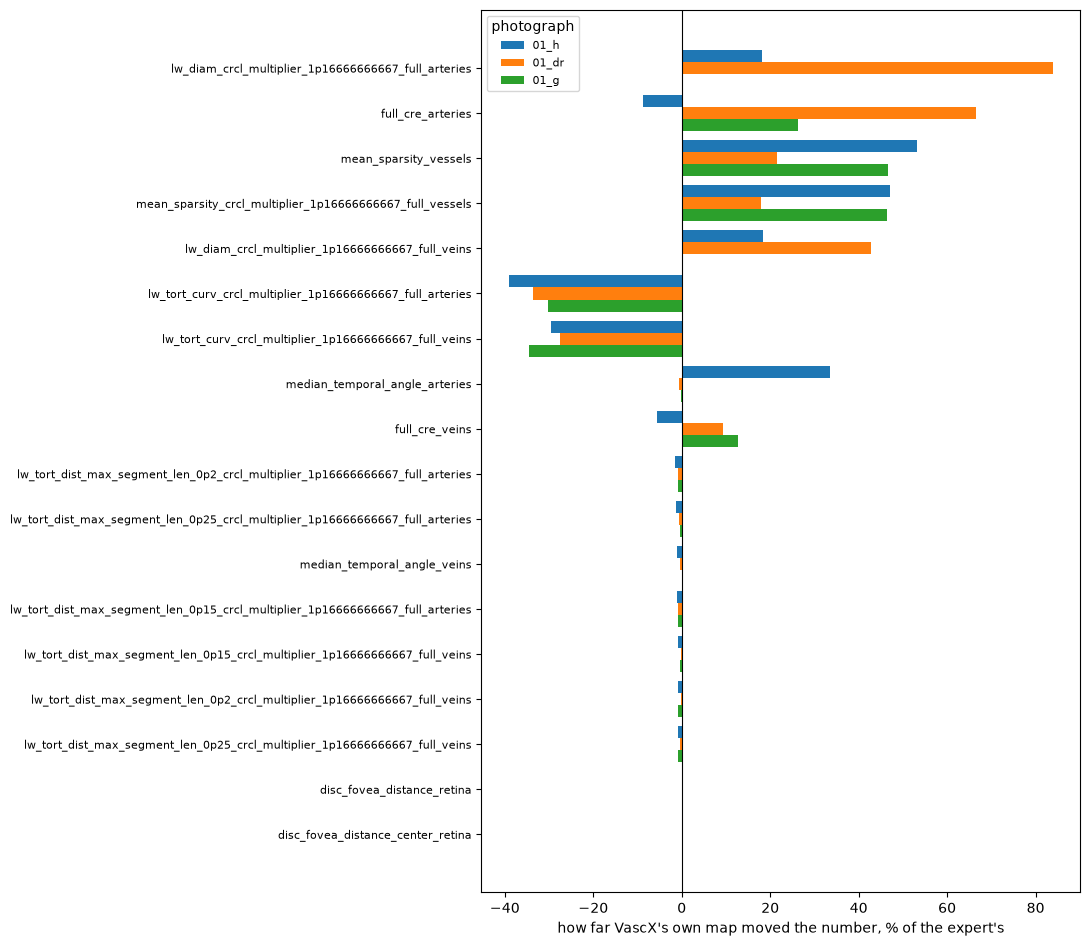

,01_h,01_dr,01_g
VascX's own name,,,
lw_diam_crcl_multiplier_1p16666666667_full_arteries,18.0,83.9,NaN
full_cre_arteries,-8.8,66.5,26.3
mean_sparsity_vessels,53.2,21.4,46.6
mean_sparsity_crcl_multiplier_1p16666666667_full_vessels,47.0,17.8,46.4
lw_diam_crcl_multiplier_1p16666666667_full_veins,18.4,42.9,NaN
lw_tort_curv_crcl_multiplier_1p16666666667_full_arteries,-39.1,-33.6,-30.2
lw_tort_curv_crcl_multiplier_1p16666666667_full_veins,-29.5,-27.4,-34.6
median_temporal_angle_arteries,33.5,-0.5,-0.1
full_cre_veins,-5.6,9.2,12.7


In [6]:
moves = pd.DataFrame(
    {key: comparison(key)["moved, %"] for key in KEYS}
).dropna(how="all")
moves = moves.reindex(moves.abs().max(axis=1).sort_values(ascending=False).index)

figure, axis = plt.subplots(figsize=(11, 0.42 * len(moves) + 2))
positions = np.arange(len(moves))
width = 0.8 / len(KEYS)
for index, key in enumerate(KEYS):
    axis.barh(positions + index * width, moves[key], height=width, label=key)
axis.set_yticks(positions + width * (len(KEYS) - 1) / 2)
axis.set_yticklabels(moves.index, fontsize=8)
axis.invert_yaxis()
axis.axvline(0, color="black", linewidth=0.8)
axis.set_xlabel("how far VascX's own map moved the number, % of the expert's")
axis.legend(title="photograph", fontsize=8)
figure.tight_layout()
plt.show()

moves.round(1)

## 5. What this does not say

- **That the expert is right.** HRF's artery/vein standard is one group's tracing with no second
  reader to compare it against, so nothing here measures human disagreement. A quantity where the
  two columns differ by less than two readers would is not distinguishable from agreement.
- **That three photographs are a result.** They are three, chosen one per disease group, and they
  are here to be looked at rather than averaged. Nothing in this notebook is committed as evidence
  and no table above belongs on a results page.
- **That a micron here is a micron.** The scale is inferred, not published — see the top of this
  notebook. Every absolute length below carries that assumption; every ratio and every percentage
  in section 4 does not.
- **That the disc is right either.** It comes from a model, and
  [the disc benchmark](../../docs/benchmarks/disc-results.md) is where that model is measured
  against ophthalmologists' own outlines. A disc-anchored quantity inherits whatever that model got
  wrong, equally in both columns.
- **That this is VascX's segmenter at its best.** The masks come from the artery/vein benchmark's
  run at that benchmark's settings. Five other models have maps for these same photographs in
  `.atlas_runs/av/`, and pointing `PREDICTED` at one of them is the whole change needed to ask the
  same question of a different segmenter.

**Where this would go if it stopped being work in progress.** The question it asks —
*what does a segmentation error cost a biomarker* — belongs to a benchmark of its own, over whole
datasets rather than three photographs, with the several artery/vein models this atlas already
runs. `PLAN-BENCHMARK.md` is where that would be proposed.